В цьому домашньому завданні ми побудуємо рішення задачі логістичної регресії і створимо ваш перший submission на змагання на Kaggle. Усі кроки були розглянуті в лекції та містяться в ноутбуці `Логістична регресія з ScikitLearn. Повна ML задача.ipynb`, але тепер ми їх адаптуємо до іншої задачі - все як в реальному житті, коли ви знайшли код у відкритих джерелах і адаптуєте на проєкті 😉

**Погнали! 🚀🚀🚀**

-----------



0. Завантажте дані `train.csv`, `test.csv`, `sample_submission.csv` зі змагання на Kaggle - шукайте посилання в уроці [Запрошення до участі у Kaggle-змаганні.](https://data-loves.kwiga.com/courses/machine-learning-dlia-liudei/domashnie-zavdannia-zmagannia-z-kaggle) Для завантаження потрібно долучитись до змагання (натиснути кнопку "Join").

1. Зчитайте дані `train.csv` в pandas dataframe та розбийте їх на train і validation піднабори.

  * Є такий параметр в методі train_test_split як stratified. Можливо він буде Вам корисним при розбитті даних в цій задачі. Пропоную Вам почитати про нього в документації і спробувати скористатись.

**Імпорти**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_curve, auc, roc_auc_score, RocCurveDisplay
from sklearn.metrics import f1_score
import joblib

Файли завантажено на диск. Підключаємось до диску та зчитуємо файл з тренувальними даними. Колонку `id` запису зробимо одразу індексом

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
train_raw_df = pd.read_csv('/content/drive/MyDrive/ML DS/Module 2/Bank Customer Churn Prediction/train.csv', index_col=0)

Прев'ю завантажених даних:

In [5]:
train_raw_df.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
id,,,,,,,,,,,,,
0,15779985.0,Nwankwo,678.0,France,Male,29.0,4.0,0.00,3.0,1.0,0.0,180626.36,0.0
1,15650086.0,Ch'in,687.0,France,Female,34.0,1.0,0.00,2.0,0.0,1.0,63736.17,0.0
2,15733602.0,Thompson,682.0,France,Female,52.0,6.0,0.00,3.0,0.0,0.0,179655.87,1.0
3,15645794.0,Macleod,753.0,Germany,Male,44.0,6.0,83347.25,2.0,1.0,0.0,161407.48,0.0
4,15633840.0,Hsia,544.0,Germany,Female,55.0,0.0,107747.57,1.0,1.0,0.0,176580.86,1.0


Набір даних включає наступні атрибути:

- **ID**: Унікальний ідентифікатор рядка  
- **Customer ID**: Унікальний ідентифікатор для кожного клієнта (це поле містить дублікати для різної інформації клієнтів, тому його просто видаляємо)  
- **Surname**: Прізвище клієнта  
- **Credit Score**: Числове значення, що представляє кредитний рейтинг клієнта  
- **Geography**: Країна, де проживає клієнт (Франція, Іспанія або Німеччина)  
- **Gender**: Стать клієнта (Чоловік або Жінка)  
- **Age**: Вік клієнта  
- **Tenure**: Кількість років, які клієнт обслуговується в банку  
- **Balance**: Баланс рахунку клієнта  
- **NumOfProducts**: Кількість банківських продуктів, які використовує клієнт (наприклад, ощадний рахунок, кредитна картка)  
- **HasCrCard**: Чи має клієнт кредитну картку (1 = так, 0 = ні)  
- **IsActiveMember**: Чи є клієнт активним членом (1 = так, 0 = ні)  
- **EstimatedSalary**: Оціночна зарплата клієнта  
- **Exited**: Чи залишив клієнт банк (1 = так, 0 = ні)  

In [6]:
train_raw_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15000 entries, 0 to 14999
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerId       15000 non-null  float64
 1   Surname          15000 non-null  object 
 2   CreditScore      15000 non-null  float64
 3   Geography        15000 non-null  object 
 4   Gender           15000 non-null  object 
 5   Age              15000 non-null  float64
 6   Tenure           15000 non-null  float64
 7   Balance          15000 non-null  float64
 8   NumOfProducts    15000 non-null  float64
 9   HasCrCard        15000 non-null  float64
 10  IsActiveMember   15000 non-null  float64
 11  EstimatedSalary  15000 non-null  float64
 12  Exited           15000 non-null  float64
dtypes: float64(10), object(3)
memory usage: 1.6+ MB


Набір тренувальних даних містить 15,000 рядків та 13 стовпців.  
У датасеті немає пропущених значень.   
Типи даних у колонках:
- категоріальні (3): `Surname`, `Geography`, `Gender`
- числові (9) + цільова змінна `Exited`

In [7]:
train_raw_df['Exited'].value_counts(normalize=True)

,proportion
Exited,
0.0,0.796533
1.0,0.203467


Оскільки рядків даних менше 100к, розподіл тренувальних даних на тренувальні та валідаційні буде здійснено у співвідношенні 80/20.   

Також через нерівномірний розподіл даних відносно значень цільової змінної (80/20 негативних та похитивних значень) звичайне розподілення тренувальних та валідаційних даних може спричинити ситуацію, коли в якомусь із наборів буде дуже мало рядків із позитивним значенням цільової змінної, що влине на оцінку якості моделі на тренувальних та валідаційних даних.  

У зв'язку з цим розділення на тренувальні та валідаційні дані краще розділити за допомогою стратифікації.

In [15]:
? train_test_split

In [8]:
train_df, val_df = train_test_split(train_raw_df, test_size=0.2, random_state=42, stratify=train_raw_df['Exited'])

Перевіримо розподіл цільових змінних у наборах даних:

In [9]:
print("test_raw_df:\n", train_raw_df['Exited'].value_counts(normalize=True))
print("\ntrain_df:\n", train_df['Exited'].value_counts(normalize=True))
print("\nval_df:\n", val_df['Exited'].value_counts(normalize=True))

test_raw_df:
 Exited
0.0    0.796533
1.0    0.203467
Name: proportion, dtype: float64

train_df:
 Exited
0.0    0.7965
1.0    0.2035
Name: proportion, dtype: float64

val_df:
 Exited
0.0    0.796667
1.0    0.203333
Name: proportion, dtype: float64


Отримали однаковий розподіл значень цільових змінних для тренувального та валідаційного набору даних

In [10]:
print('train_df.shape :', train_df.shape)
print('val_df.shape :', val_df.shape)

train_df.shape : (12000, 13)
val_df.shape : (3000, 13)


2. Визначіть назви колонок, які сформують вхідні незалежні дані, в змінній `input_cols` та назву колонки , яка є цільовою, в змінній `target_col`. Використовуючи `input_cols` та `target_col` створіть набори даних `train_inputs`, `train_targets`, `val_inputs`, `val_targets` - де `inputs` - вхідні дані (датафрейм), `targets` - дані цільової колонки відповідного піднабору.

Припускаємо, що колонка з прізвищем може бути виключена з наборів даних, оскільки модель повинна аналізувати дані та передбачати значення за патернами операцій та поведінки користувача, а не прив'язуватися до конкретного прізвища.

Аналогічно всі колонки з ідентифікаторами id, оскільки модель також має бути неупереджена щодо такого типу інформації про клієнтів.

In [11]:
input_cols = [col for col in train_df.columns[2:-1]]
target_col = 'Exited'

In [12]:
print('Input columns:', input_cols)
print('\nTraget column:', target_col)

Input columns: ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']

Traget column: Exited


In [13]:
train_inputs = train_df[input_cols].copy()
train_targets = train_df[target_col].copy()

val_inputs = val_df[input_cols].copy()
val_targets = val_df[target_col].copy()

In [14]:
train_inputs.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
id,,,,,,,,,,
7180,682.0,France,Male,30.0,1.0,131394.56,1.0,1.0,1.0,143952.24
10393,684.0,France,Female,39.0,2.0,178058.06,1.0,1.0,0.0,145518.31
80,705.0,Germany,Male,35.0,6.0,116320.68,2.0,1.0,0.0,174431.01
3365,669.0,Spain,Male,58.0,0.0,0.00,2.0,0.0,1.0,51565.98
12236,707.0,France,Male,21.0,3.0,0.00,2.0,1.0,1.0,148564.76


In [15]:
val_inputs.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
id,,,,,,,,,,
6490,714.0,Germany,Male,46.0,1.0,115764.32,4.0,1.0,1.0,72945.32
3646,593.0,France,Male,41.0,5.0,0.00,2.0,1.0,1.0,38196.24
5306,731.0,France,Female,38.0,2.0,0.00,2.0,0.0,1.0,116971.05
652,673.0,France,Female,43.0,4.0,155739.76,1.0,0.0,1.0,111622.76
2627,678.0,Spain,Female,30.0,4.0,0.00,2.0,1.0,0.0,143681.85


3. Визначіть з допомогою `pandas.DataFrame.select_dtypes` назви колонок, які є числовими і категоріальними. Запишіть результати в `numeric_cols` та `categorical_cols` відповідно.

In [16]:
numeric_cols = train_inputs.select_dtypes(include=np.number).columns.tolist()
categorical_cols = train_inputs.select_dtypes('object').columns.tolist()

In [17]:
print('Numeric columns:', numeric_cols)
print('\nCategorical columns:', categorical_cols)

Numeric columns: ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']

Categorical columns: ['Geography', 'Gender']


4. Зробіть підготовку даних в категоріальних і числових колонках для входу в модель виходячи з освоєного на даний момент на курсі. Варіанти пеердобробки, з якими ми вже знайомі:
  - масштабування числових ознак,
  - заповнення пропущених значень, якщо вони є,
  - кодування категоріальних ознак, вилучення ознак, якщо ми вважаємо, що ці дані нерелевантні для моделі аби ми не бачимо способу як їх так закодувати, аби подати на вхід моделі.

  Тут є багато варіантів, як Ви побудуєте передобробку, важливо аби
  1) передобробка мала сенс (немає сенсу заповнювати дані константою, яку ми не зрозуміло звідки взяли)   
  2) має бути виконана принаймні одна дія передобробки
  3) обробка маэ бути виконана коректно і для тренувальних, і для вал. даних
  4) чим вищий у Вас врешті вийде ROС AUC скор, тим більше шансів перемогти у змаганні :)

  Опишіть рішення проведення кожного з кроків передобробки. Для чого ви його робите? По завершенню виведіть по 5 значен з `train_inputs`, `val_inputs` використовуючи `display()`.

4.1. Підготовка числових стовпців

Перевіримо спочатку адекватність числових даних у стовпцях:

In [18]:
train_inputs[numeric_cols].describe().round(2)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
count,12000.00,12000.00,12000.00,12000.00,12000.00,12000.00,12000.00,12000.00
mean,658.84,37.69,5.03,43008.17,1.59,0.79,0.49,117992.40
std,72.33,8.14,2.78,59906.63,0.53,0.41,0.50,45589.48
min,431.00,18.00,0.00,0.00,1.00,0.00,0.00,11.58
25%,603.00,32.00,3.00,0.00,1.00,1.00,0.00,83343.73
50%,661.00,37.00,5.00,0.00,2.00,1.00,0.00,123613.91
75%,708.00,42.00,7.00,109949.05,2.00,1.00,1.00,156912.81
max,850.00,74.00,10.00,209767.31,4.00,1.00,1.00,199992.48


Дані виглядають адекватно, без аномалій

In [19]:
train_raw_df[numeric_cols].isna().sum()

,0
CreditScore,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0
HasCrCard,0
IsActiveMember,0
EstimatedSalary,0


Як і перевіряли раніше, пропущених значень в початковому наборі даних немає

Здійснимо масштабування числових ознак для уникнення непропорційного впливу конкретних ознак на втрати моделі.   
Використаємо метод **масштабування Min-Max**

In [20]:
scaler = MinMaxScaler()

In [21]:
scaler.fit(train_inputs[numeric_cols])

MinMaxScaler()

Масштабуємо тренувальні та валідаційні дані

In [35]:
train_inputs[numeric_cols] = scaler.transform(train_inputs[numeric_cols])
val_inputs[numeric_cols] = scaler.transform(val_inputs[numeric_cols])

In [36]:
train_inputs[numeric_cols].describe().round(2)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
count,12000.00,12000.00,12000.00,12000.00,12000.00,12000.00,12000.00,12000.00
mean,0.54,0.35,0.50,0.21,0.20,0.79,0.49,0.59
std,0.17,0.15,0.28,0.29,0.18,0.41,0.50,0.23
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.41,0.25,0.30,0.00,0.00,1.00,0.00,0.42
50%,0.55,0.34,0.50,0.00,0.33,1.00,0.00,0.62
75%,0.66,0.43,0.70,0.52,0.33,1.00,1.00,0.78
max,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00


In [37]:
val_inputs[numeric_cols].describe().round(2)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
count,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00
mean,0.55,0.36,0.50,0.20,0.20,0.78,0.48,0.58
std,0.17,0.15,0.28,0.28,0.18,0.41,0.50,0.23
min,0.01,0.02,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.41,0.25,0.30,0.00,0.00,1.00,0.00,0.41
50%,0.55,0.34,0.50,0.00,0.33,1.00,0.00,0.61
75%,0.66,0.43,0.70,0.51,0.33,1.00,1.00,0.78
max,1.00,0.96,1.00,0.89,1.00,1.00,1.00,1.00


Тепер всі значення в кожному стовпці лежать в діапазоні $(0,1)$

4.2. Підготовка категоріальних стовпців

Перевіримо кількість унікальних значень в кожній категоріальній колонці у тестових вхідних та розбитих даних

In [38]:
display(train_raw_df[categorical_cols].nunique())
display(train_df[categorical_cols].nunique())

,0
Geography,3
Gender,2


,0
Geography,3
Gender,2


In [39]:
display(train_df['Geography'].value_counts())
display(train_df['Gender'].value_counts())

,count
Geography,
France,7211
Spain,2638
Germany,2151


,count
Gender,
Male,6876
Female,5124


Отже, для колонки `Gender` можна застосувати бінарне кодування (наприклад, Male=1, Female=0), та для зручності використаємо one-hot encoder з відкиданням першої колонки.
Для колонки `Geography` застосуємо one-hot encoder, виключивши одне із значень для уникнення мультиколінеарності

In [22]:
encoder = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')

In [23]:
encoder.fit(train_inputs[categorical_cols])

OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)

In [24]:
encoder.categories_

[array(['France', 'Germany', 'Spain'], dtype=object),
 array(['Female', 'Male'], dtype=object)]

Отримали наступні категорії для кодування колонок:

In [30]:
encoded_cols = list(encoder.get_feature_names_out(categorical_cols))
encoded_cols

['Geography_Germany', 'Geography_Spain', 'Gender_Male']

In [40]:
train_inputs[encoded_cols] = encoder.transform(train_inputs[categorical_cols])
val_inputs[encoded_cols] = encoder.transform(val_inputs[categorical_cols])

In [41]:
display(train_inputs.head())
display(val_inputs.head())

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
id,,,,,,,,,,,,,
7180,0.599045,France,Male,0.214286,0.1,0.626382,0.000000,1.0,1.0,0.719772,0.0,0.0,1.0
10393,0.603819,France,Female,0.375000,0.2,0.848836,0.000000,1.0,0.0,0.727603,0.0,0.0,0.0
80,0.653938,Germany,Male,0.303571,0.6,0.554522,0.333333,1.0,0.0,0.872180,1.0,0.0,1.0
3365,0.568019,Spain,Male,0.714286,0.0,0.000000,0.333333,0.0,1.0,0.257797,0.0,1.0,1.0
12236,0.658711,France,Male,0.053571,0.3,0.000000,0.333333,1.0,1.0,0.742837,0.0,0.0,1.0


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
id,,,,,,,,,,,,,
6490,0.675418,Germany,Male,0.500000,0.1,0.551870,1.000000,1.0,1.0,0.364704,1.0,0.0,1.0
3646,0.386635,France,Male,0.410714,0.5,0.000000,0.333333,1.0,1.0,0.190942,0.0,0.0,1.0
5306,0.715990,France,Female,0.357143,0.2,0.000000,0.333333,0.0,1.0,0.584853,0.0,0.0,0.0
652,0.577566,France,Female,0.446429,0.4,0.742441,0.000000,0.0,1.0,0.558109,0.0,0.0,0.0
2627,0.589499,Spain,Female,0.214286,0.4,0.000000,0.333333,1.0,0.0,0.718420,0.0,1.0,0.0


5. Збережіть дані, що містяться в змінних `train_inputs`, `train_targets`, `val_inputs`, `val_targets` на диск в форматі `parquet`. В кінці виведіть список файлів в папці, в яку Ви зберегли файли і перевірте, чи файли збереглись. Вивести список файлів можна з `os.listdir(your_dir)` або `!ls your_dir`

In [42]:
print('train_inputs:', train_inputs.shape)
print('train_targets:', train_targets.shape)
print('val_inputs:', val_inputs.shape)
print('val_targets:', val_targets.shape)

train_inputs: (12000, 13)
train_targets: (12000,)
val_inputs: (3000, 13)
val_targets: (3000,)


Отримані дані збережемо в parquet форматі

In [25]:
save_path = '/content/drive/MyDrive/ML DS/Module 2/Bank Customer Churn Prediction/'

In [43]:
train_inputs.to_parquet(save_path + 'train_inputs.parquet')
val_inputs.to_parquet(save_path + 'val_inputs.parquet')
pd.DataFrame(train_targets).to_parquet(save_path +'train_targets.parquet')
pd.DataFrame(val_targets).to_parquet(save_path + 'val_targets.parquet')

Код для зчитування даних:

In [31]:
target_col = 'Exited'

In [19]:
train_inputs = pd.read_parquet(save_path + 'train_inputs.parquet')
val_inputs = pd.read_parquet(save_path + 'val_inputs.parquet')

train_targets = pd.read_parquet(save_path + 'train_targets.parquet')[target_col]
val_targets = pd.read_parquet(save_path + 'val_targets.parquet')[target_col]

In [20]:
print('train_inputs:', train_inputs.shape)
print('train_targets:', train_targets.shape)
print('val_inputs:', val_inputs.shape)
print('val_targets:', val_targets.shape)

train_inputs: (12000, 13)
train_targets: (12000,)
val_inputs: (3000, 13)
val_targets: (3000,)


6. З підготовлених вхідних даних створіть `X_train`, `X_val` набори, які містять лише колонки, які підуть на вхід моделі. Навчіть модель бінарної класифікації з допомогою `LogisticRegression` в `scikit-learn`.

In [44]:
display(train_inputs.head())
display(val_inputs.head())

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
id,,,,,,,,,,,,,
7180,0.599045,France,Male,0.214286,0.1,0.626382,0.000000,1.0,1.0,0.719772,0.0,0.0,1.0
10393,0.603819,France,Female,0.375000,0.2,0.848836,0.000000,1.0,0.0,0.727603,0.0,0.0,0.0
80,0.653938,Germany,Male,0.303571,0.6,0.554522,0.333333,1.0,0.0,0.872180,1.0,0.0,1.0
3365,0.568019,Spain,Male,0.714286,0.0,0.000000,0.333333,0.0,1.0,0.257797,0.0,1.0,1.0
12236,0.658711,France,Male,0.053571,0.3,0.000000,0.333333,1.0,1.0,0.742837,0.0,0.0,1.0


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
id,,,,,,,,,,,,,
6490,0.675418,Germany,Male,0.500000,0.1,0.551870,1.000000,1.0,1.0,0.364704,1.0,0.0,1.0
3646,0.386635,France,Male,0.410714,0.5,0.000000,0.333333,1.0,1.0,0.190942,0.0,0.0,1.0
5306,0.715990,France,Female,0.357143,0.2,0.000000,0.333333,0.0,1.0,0.584853,0.0,0.0,0.0
652,0.577566,France,Female,0.446429,0.4,0.742441,0.000000,0.0,1.0,0.558109,0.0,0.0,0.0
2627,0.589499,Spain,Female,0.214286,0.4,0.000000,0.333333,1.0,0.0,0.718420,0.0,1.0,0.0


In [45]:
X_train = train_inputs[numeric_cols + encoded_cols]
X_val = val_inputs[numeric_cols + encoded_cols]

In [46]:
model = LogisticRegression(solver='liblinear')

In [47]:
model.fit(X_train, train_targets)

LogisticRegression(solver='liblinear')

Ваги та зміщення моделі:

In [48]:
print(X_train.columns.tolist())
print(model.coef_.round(2).tolist())
print(model.intercept_.round(2))

['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography_Germany', 'Geography_Spain', 'Gender_Male']
[[-0.89, 8.43, -0.08, -1.09, -3.94, -0.19, -1.25, 0.18, 1.56, -0.1, -0.86]]
[-2.6]


7. Виведіть Confusion matrix, ROC Curve, метрику AUROC та метрику F1 Score для порога класифікації 0.5 для побудованої моделі на тренувальних та валідаційних даних. Що можете сказати про якіст моделі? Вона хороша, погана, задовільна?

Прогнози моделі мають числовий формат:

In [49]:
train_preds = model.predict(X_train)
train_preds

array([0., 0., 0., ..., 0., 0., 0.])

In [50]:
def predict_and_plot(inputs, targets, name=''):
    preds = model.predict(inputs)

    accuracy = accuracy_score(targets, preds)
    print("Accuracy: {:.2f}%".format(accuracy * 100))

    cf = confusion_matrix(targets, preds, normalize='true')
    plt.figure()
    sns.heatmap(cf, annot=True)
    plt.xlabel('Prediction')
    plt.ylabel('Target')
    plt.title('{} Confusion Matrix'.format(name));

    return preds

In [51]:
confusion_matrix(train_targets, train_preds)

array([[9176,  382],
       [1126, 1316]])

Accuracy: 87.43%


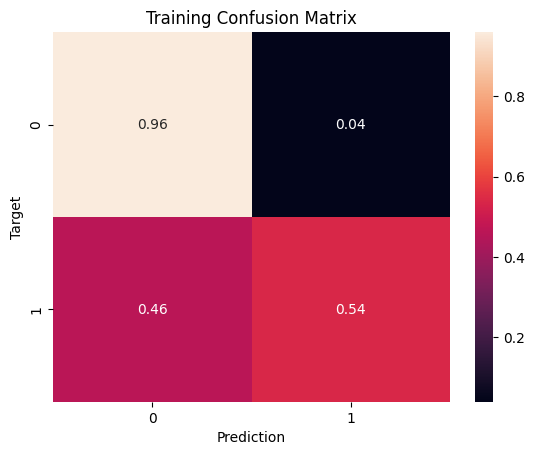

In [52]:
train_confusions = predict_and_plot(X_train, train_targets, 'Training')

Accuracy: 87.13%


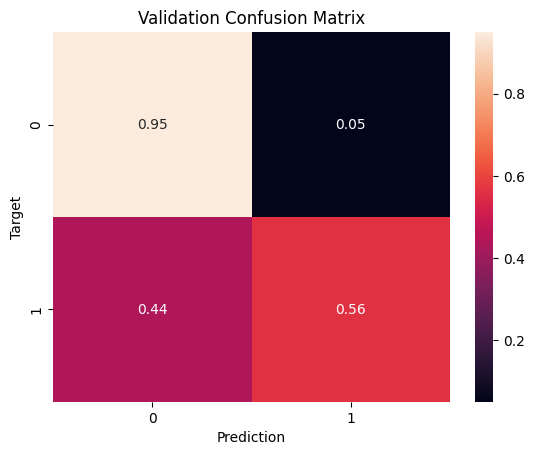

In [53]:
val_confusions = predict_and_plot(X_val, val_targets, 'Validation')

Для тренувальних та валідаційних даних бачимо приблизно однаковий результат для матриці невідповідностей та розрахованої точності. Також беремо до уваги, що дані по категоріях не збалансовані 50/50, тому Accuracy недоречно використовувати для оцінки даної моделі.

Оцінимо точність моделі за ROC Curve, AUROC, F1-Score

Побудуємо ROC Curve та обчислимо AUROC (площу під кривою)

In [54]:
def compute_auroc_and_build_roc(inputs, targets, name=''):
  # Predict probabilities
  y_pred_proba = model.predict_proba(inputs)[:, 1]

  # Compute ROC curve
  fpr, tpr, thresholds = roc_curve(targets, y_pred_proba)

    # Compute AUROC
  roc_auc = auc(fpr, tpr)
  print(f'AUROC for {name}: {roc_auc:.2f}')

  # Plot the ROC curve
  plt.figure()
  plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
  plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
  plt.xlim([0.0, 1.0])
  plt.ylim([0.0, 1.05])
  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')
  plt.title(f'Receiver Operating Characteristic (ROC) Curve for {name}')
  plt.legend(loc="lower right")
  plt.show()

AUROC for Training: 0.88


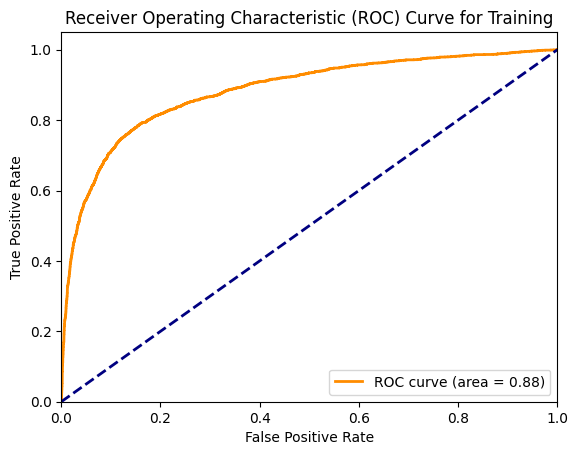

AUROC for Validation: 0.88


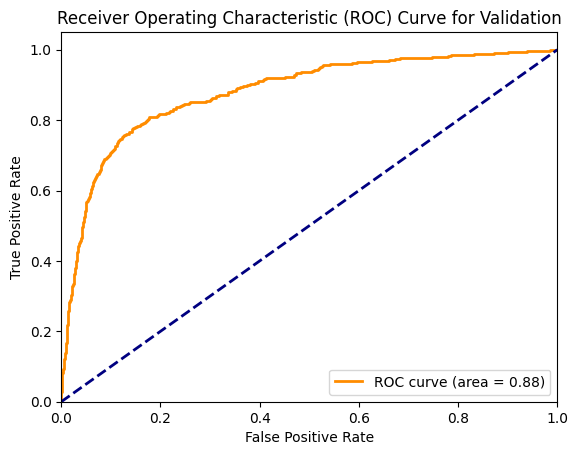

In [55]:
compute_auroc_and_build_roc(X_train, train_targets, 'Training')
compute_auroc_and_build_roc(X_val, val_targets, 'Validation')

Бачимо, що значення AUROC для обох наборів однакові, криві також виглядають подібно

Визначимо також F1-Score

In [56]:
def get_f1_score(inputs, targets, name=''):
  preds = model.predict(inputs)

  f1_score_ = f1_score(targets, preds)
  print(f"F1 score {name}: {f1_score_*100:.2f}%")

get_f1_score(X_train, train_targets, 'Training')
get_f1_score(X_val, val_targets, 'Validation')

F1 score Training: 63.57%
F1 score Validation: 63.99%


Отримали однакові результати F1-Score для тренувального та валідаційного датасетів: 64%

На основі знайдених параметрів для моделі, на перший погляд можна сказати, що модель має високі показники якості.

Проте потрібно взяти до уваги, що позитивних класів у наборі даних значно менше, а також, що FN значень великий відсоток.

Тому виникає питання, наскільки ця модель краща, ніж модель, яка б завжди повертала негативні класи

8. Створіть передбачення моделі, яка передбачає завжди мажоритарний клас (той, якого більше в тренувальних даних). Порахуйте Accuracy на тренувальних та валідаційних даних для цієї моделі і тої, що ми натренували в п.6. Зробіть заключення про якість нашої моделі: якість хороша, погана, задовільна?

З матриць для моделі бачимо, що великий % значень мають TN, а виявлення позитивних класів модель здійснює погано (FN та TP майже 50/50 розподілені, тобто модель виявляє половину справді позитивних значень та помиляється з половиною позитивних значень).

Порівняємо з Accuracy моделі, яка звіжди дає мажоритарний клас (всі 0)

In [57]:
major_baseline_train = np.full(len(train_inputs), 0)
major_baseline_val = np.full(len(val_inputs), 0)

In [58]:
baseline_accuracy_train = accuracy_score(train_targets, major_baseline_train)
baseline_accuracy_val = accuracy_score(val_targets, major_baseline_val)

cf_train = confusion_matrix(train_targets, major_baseline_train, normalize='true')
cf_val = confusion_matrix(val_targets, major_baseline_val, normalize='true')

Train Baseline Accuracy: 79.65%


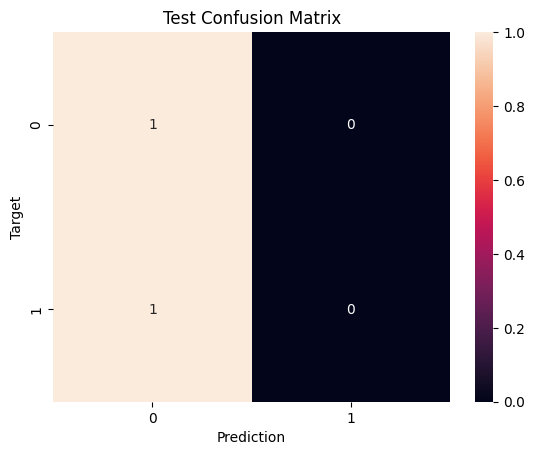

In [59]:
print("Train Baseline Accuracy: {:.2f}%".format(baseline_accuracy_train * 100))
plt.figure()
sns.heatmap(cf_train, annot=True)
plt.xlabel('Prediction')
plt.ylabel('Target')
plt.title('Test Confusion Matrix');

Validation Baseline Accuracy: 79.67%


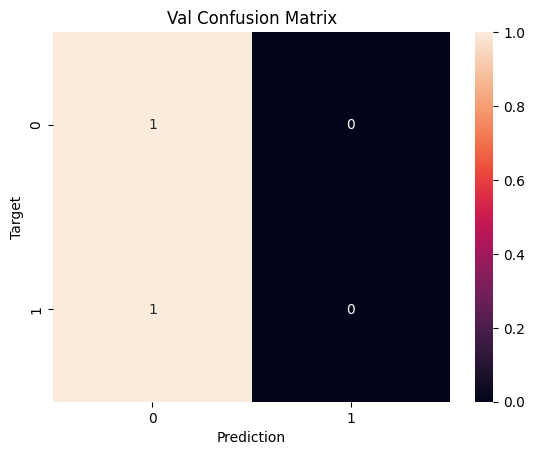

In [60]:
print("Validation Baseline Accuracy: {:.2f}%".format(baseline_accuracy_val * 100))

plt.figure()
sns.heatmap(cf_val, annot=True)
plt.xlabel('Prediction')
plt.ylabel('Target')
plt.title('Val Confusion Matrix');

Оцінена модель, яка завжди повертає мажоритарний клас (0), має також високу Accuracy (порядку 80%), що теж підтверджує наявність малої кількості позитивних класів у тренувальному наборі даних.


З усієї отриманої інформації щодо якості моделі, можна зробити висновок, що якість потрібно покращувати. Можливо, зменшити поріг, щоб модель сміливіше присвоювала позитивний клас.

9. Збережіть модель і інші обʼєкти, які ви хотіли б зберегти, з використанням бібліотеки joblib в файл `log_reg.joblib`. Потім завантажте модель з файлу в змінну `model_2` (цим ми тренуємось завантажувати модель з файлу на майбутнє).

In [55]:
model_2 = {
    'model': model,
    'scaler': scaler,
    'encoder': encoder,
    'input_cols': input_cols,
    'target_col': target_col,
    'numeric_cols': numeric_cols,
    'categorical_cols': categorical_cols,
    'encoded_cols': encoded_cols
}

In [56]:
joblib.dump(model_2, save_path + 'model_2.joblib')

['/content/drive/MyDrive/ML DS/Module 2/Bank Customer Churn Prediction/model_2.joblib']

In [6]:
model_2 = joblib.load(save_path + 'model_2.joblib')

In [58]:
train_preds2 = model_2['model'].predict(X_train)
print(accuracy_score(train_targets, train_preds2))
print(accuracy_score(train_targets, train_preds))

0.8743333333333333
0.8743333333333333


Завантаження відбулося успішно

In [31]:
model = model_2['model']
scaler = model_2['scaler']
encoder = model_2['encoder']
numeric_cols = model_2['numeric_cols']
categorical_cols = model_2['categorical_cols']
target_col =  model_2['target_col']

10. Ознайомтесь з роботою наведеної функції `predict_raw_df`. Ця функція робить підготовку даних (масштабування числових колонок і кодування категоріальних) і виводить ймовірності належності до класу 1 для кожного рядка в наданому наборі.

Доповніть або внесіть зміни у функцію з врахуванням вашого препроцесингу даних.

In [61]:
import warnings
warnings.filterwarnings("ignore")

In [62]:
def predict_raw_df(model, scaler, encoder, numeric_cols, categorical_cols, input_df: pd.DataFrame):
    train_inputs = input_df[numeric_cols + categorical_cols].copy()
    encoded_cols = list(encoder.get_feature_names_out(categorical_cols))

    train_inputs[numeric_cols] = scaler.transform(train_inputs[numeric_cols])
    train_inputs[encoded_cols] = encoder.transform(train_inputs[categorical_cols])

    X_input = train_inputs[numeric_cols + encoded_cols]
    prob = model.predict_proba(X_input)[:,1]

    return prob

Додатково до завдання створюю функцію для всіх операцій над датафреймом включно з побудовою графіків

In [63]:
def accuracy_confusion_matrix(targets, preds, name=''):

    accuracy = accuracy_score(targets, preds)
    print("Accuracy: {:.2f}%".format(accuracy * 100))

    cf = confusion_matrix(targets, preds, normalize='true')
    plt.figure()
    sns.heatmap(cf, annot=True)
    plt.xlabel('Prediction')
    plt.ylabel('Target')
    plt.title('{} Confusion Matrix'.format(name));

    return preds

In [64]:
def auroc_and_build_roc(targets, pred_proba, name=''):

  # Compute ROC curve
  fpr, tpr, thresholds = roc_curve(targets, pred_proba)

    # Compute AUROC
  roc_auc = auc(fpr, tpr)
  print(f'AUROC for {name}: {roc_auc:.2f}')

  # Plot the ROC curve
  plt.figure()
  plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
  plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
  plt.xlim([0.0, 1.0])
  plt.ylim([0.0, 1.05])
  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')
  plt.title(f'Receiver Operating Characteristic (ROC) Curve for {name}')
  plt.legend(loc="lower right")
  plt.show()

In [65]:
def f1_scores(targets, preds, name=''):
  f1_score_ = f1_score(targets, preds)
  print(f"F1 score {name}: {f1_score_*100:.2f}%")

In [66]:
def predict_evaluate_raw_df(model, scaler, encoder, numeric_cols, categorical_cols, target_col, input_df: pd.DataFrame):
    train_df, val_df = train_test_split(input_df, test_size=0.2, random_state=42, stratify=train_raw_df[[target_col]])

    #Inputs and targets
    train_inputs = train_df[numeric_cols + categorical_cols].copy()
    train_targets = train_df[target_col].copy()
    val_inputs = val_df[numeric_cols + categorical_cols].copy()
    val_targets = val_df[target_col].copy()

    encoded_cols = list(encoder.get_feature_names_out(categorical_cols))

    # Scaler
    train_inputs[numeric_cols] = scaler.transform(train_inputs[numeric_cols])
    val_inputs[numeric_cols] = scaler.transform(val_inputs[numeric_cols])

    # Encoder
    train_inputs[encoded_cols] = encoder.transform(train_inputs[categorical_cols])
    val_inputs[encoded_cols] = encoder.transform(val_inputs[categorical_cols])

    X_train = train_inputs[numeric_cols + encoded_cols]
    X_val = val_inputs[numeric_cols + encoded_cols]

    # Probability
    prob_train = model.predict_proba(X_train)[:,1]
    prob_val = model.predict_proba(X_val)[:,1]

    # Predictions
    preds_train = model.predict(X_train)
    preds_val = model.predict(X_val)

    # Accuracy and Confusion Matrix
    accuracy_confusion_matrix(train_targets, preds_train, 'Training')
    accuracy_confusion_matrix(val_targets, preds_val, 'Validation')

    # Compute AUROC and build ROC
    auroc_and_build_roc(train_targets, prob_train, 'Training')
    auroc_and_build_roc(val_targets, prob_val, 'Validation')

    # F-1 Scores
    f1_scores(train_targets, preds_train, 'Training')
    f1_scores(val_targets, preds_val, 'Validation')

    return prob_train, prob_val

Accuracy: 87.43%
Accuracy: 87.13%
AUROC for Training: 0.88


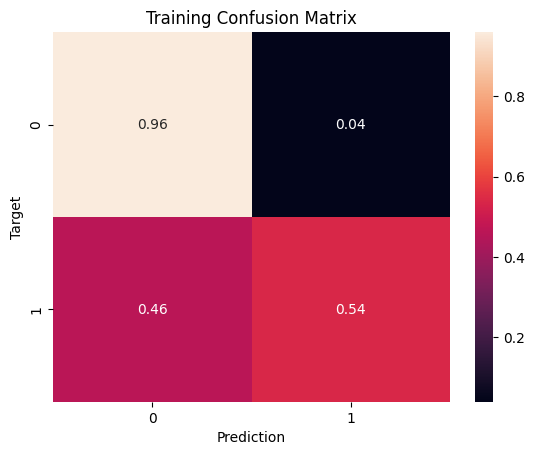

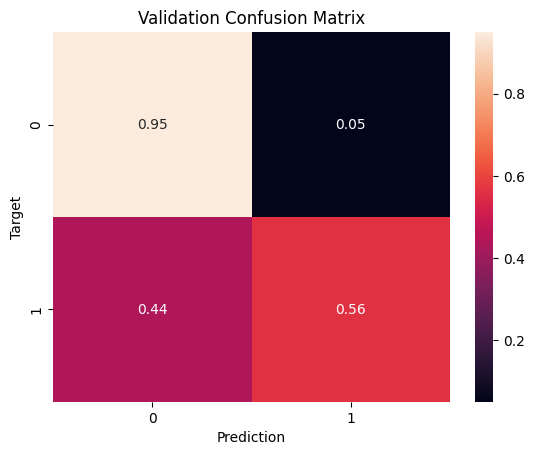

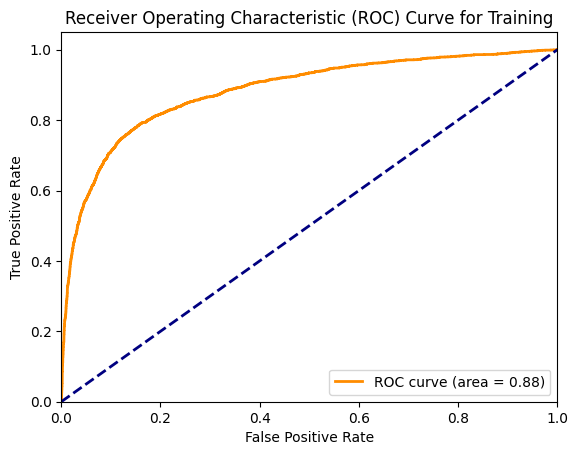

AUROC for Validation: 0.88


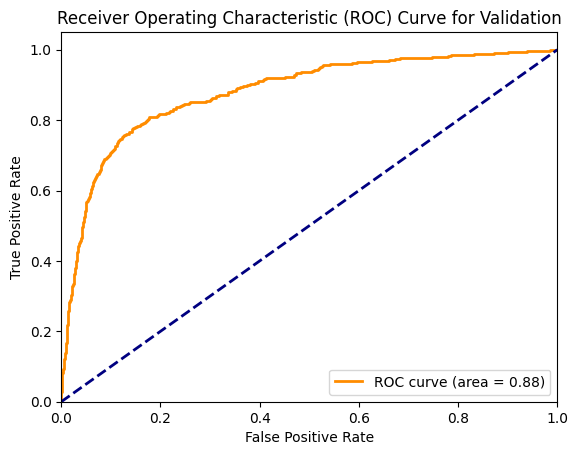

F1 score Training: 63.57%
F1 score Validation: 63.99%


(array([0.01476089, 0.27248986, 0.12645894, ..., 0.00726919, 0.16851901,
        0.05125434]),
 array([0.01444881, 0.04264337, 0.0626344 , ..., 0.03319585, 0.0579875 ,
        0.06829169]))

In [67]:
predict_evaluate_raw_df(model, scaler, encoder, numeric_cols, categorical_cols, target_col, train_raw_df)

Протестуємо ще одну модель з іншими параметрами

In [175]:
model2 = LogisticRegression(solver='liblinear', class_weight='balanced', random_state=12)

In [176]:
model2.fit(X_train, train_targets)

LogisticRegression(class_weight='balanced', random_state=12, solver='liblinear')

Accuracy: 82.29%
Accuracy: 80.83%
AUROC for Training: 0.88


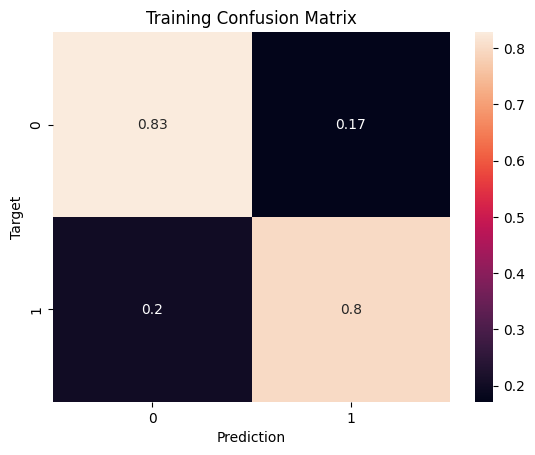

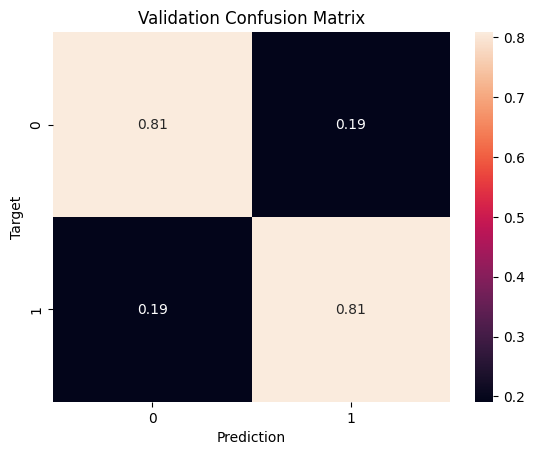

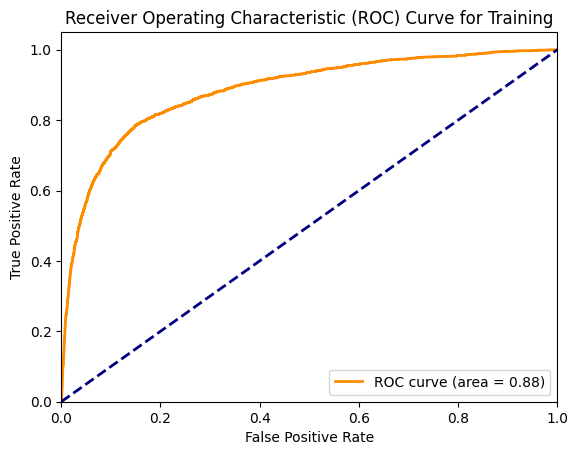

AUROC for Validation: 0.88


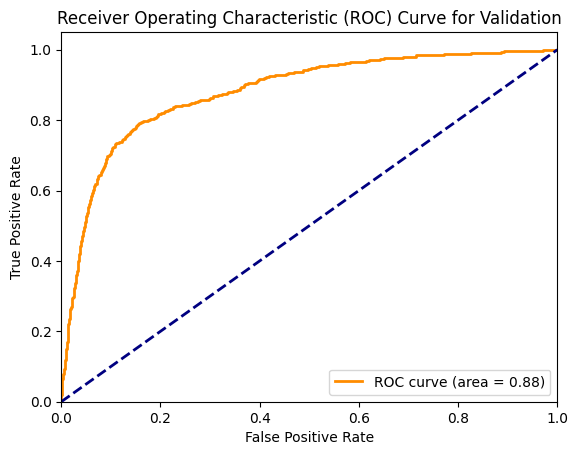

F1 score Training: 64.78%
F1 score Validation: 63.12%


(array([0.05392252, 0.5906962 , 0.36686661, ..., 0.02842265, 0.43218922,
        0.15434148]),
 array([0.10640819, 0.16547694, 0.22438534, ..., 0.10634727, 0.17253162,
        0.2372298 ]))

In [177]:
predict_evaluate_raw_df(model2, scaler, encoder, numeric_cols, categorical_cols, target_col, train_raw_df)

Отримані результати для моделі 2 гірші за показниками F1-Score, проте матриця невідповідностей краща

Створимо та натренуємо ще одну модель, в якій додамо параметр регуляризації L1 (Lasso), в якому в моделі залишаються лише значущі коефіцієнти.

In [71]:
model3 = LogisticRegression(solver='liblinear', penalty='l1', class_weight='balanced', random_state=42)

In [72]:
model3.fit(X_train, train_targets)

LogisticRegression(class_weight='balanced', penalty='l1', random_state=42,
                   solver='liblinear')

Accuracy: 82.40%
Accuracy: 80.93%
AUROC for Training: 0.88


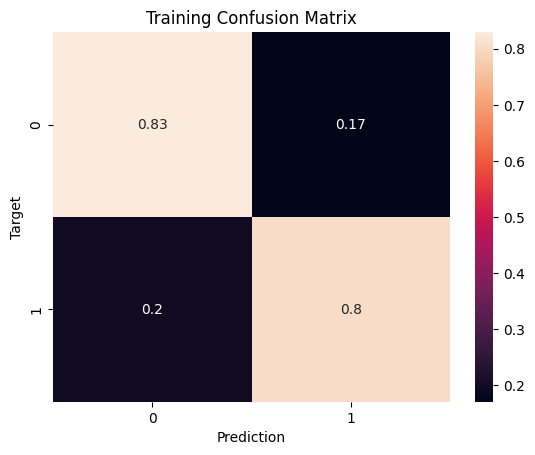

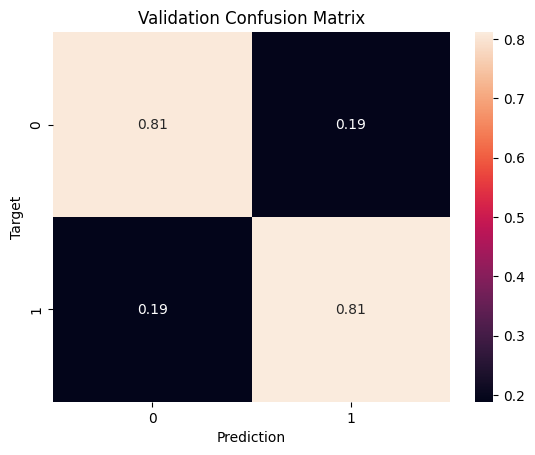

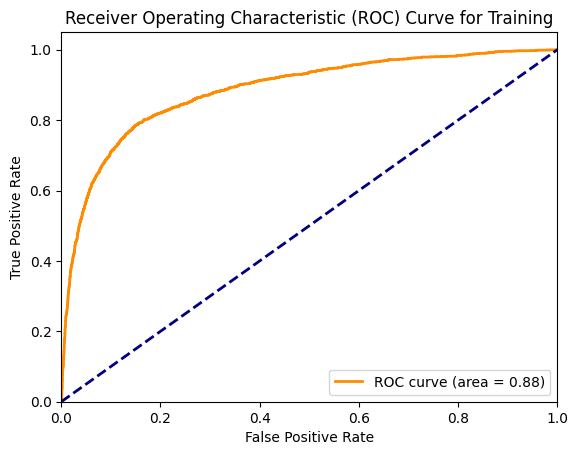

AUROC for Validation: 0.88


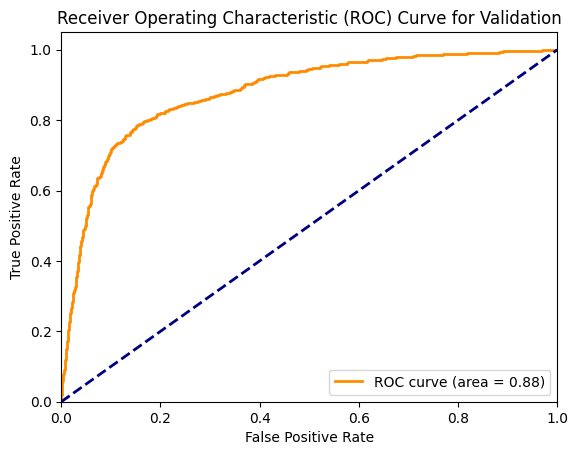

F1 score Training: 64.96%
F1 score Validation: 63.38%


(array([0.05025309, 0.58920771, 0.36041264, ..., 0.02629864, 0.43389731,
        0.14400936]),
 array([0.10548422, 0.16404943, 0.21953702, ..., 0.10140104, 0.1669092 ,
        0.23657293]))

In [73]:
predict_evaluate_raw_df(model3, scaler, encoder, numeric_cols, categorical_cols, target_col, train_raw_df)

Також натренуємо ще модель, змінивши параметр C з дефолтного 1 на 0.1

In [83]:
model4 = LogisticRegression(solver='liblinear', penalty='l1', class_weight='balanced', random_state=42, C=0.1)

In [84]:
model4.fit(X_train, train_targets)

LogisticRegression(C=0.1, class_weight='balanced', penalty='l1',
                   random_state=42, solver='liblinear')

Accuracy: 82.31%
Accuracy: 80.90%
AUROC for Training: 0.88


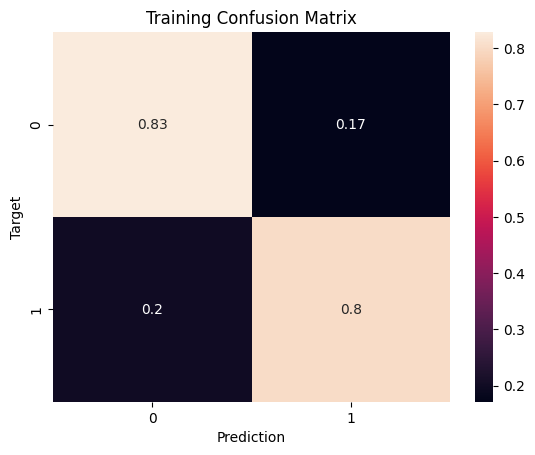

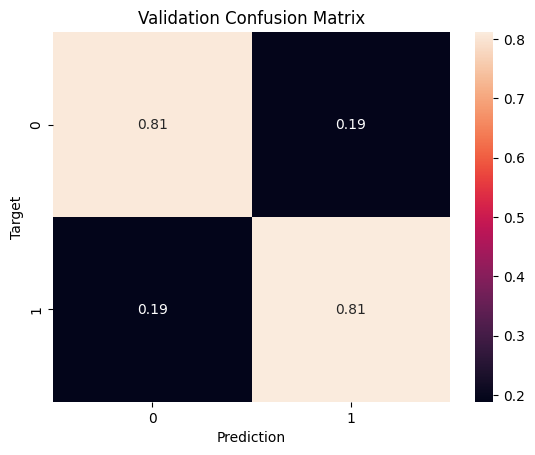

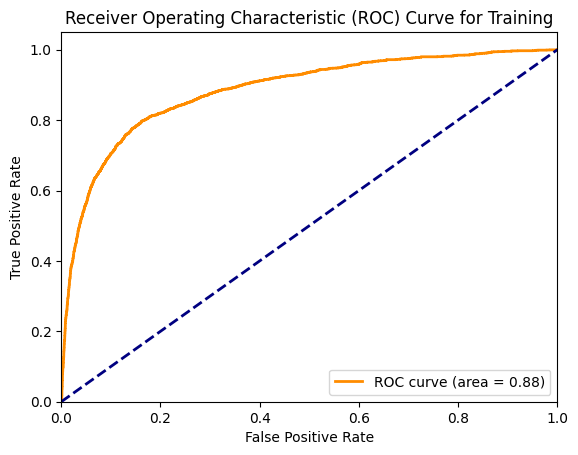

AUROC for Validation: 0.88


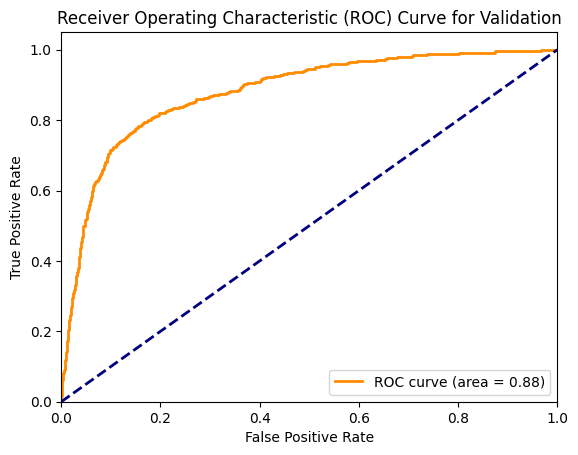

F1 score Training: 64.87%
F1 score Validation: 63.34%


(array([0.05914333, 0.60541355, 0.36336262, ..., 0.03046695, 0.443017  ,
        0.15629526]),
 array([0.11903669, 0.17723305, 0.22791796, ..., 0.10836779, 0.19436217,
        0.25782429]))

In [85]:
predict_evaluate_raw_df(model4, scaler, encoder, numeric_cols, categorical_cols, target_col, train_raw_df)

In [80]:
model5 = LogisticRegression(solver='liblinear', penalty='l2', class_weight='balanced', random_state=42, C=0.1)

In [81]:
model5.fit(X_train, train_targets)

LogisticRegression(C=0.1, class_weight='balanced', random_state=42,
                   solver='liblinear')

Accuracy: 81.77%
Accuracy: 80.40%
AUROC for Training: 0.88


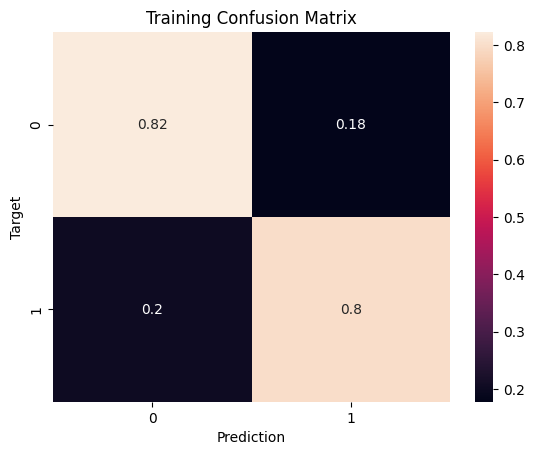

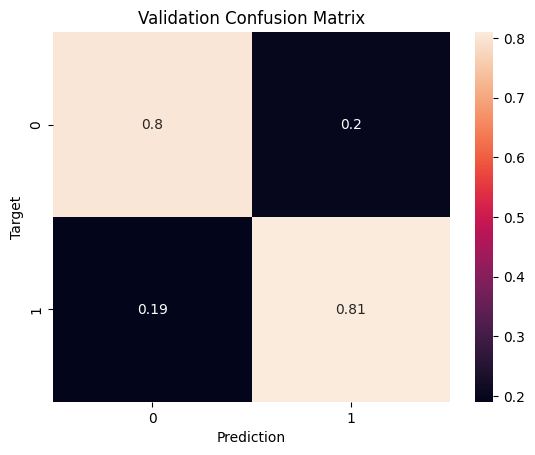

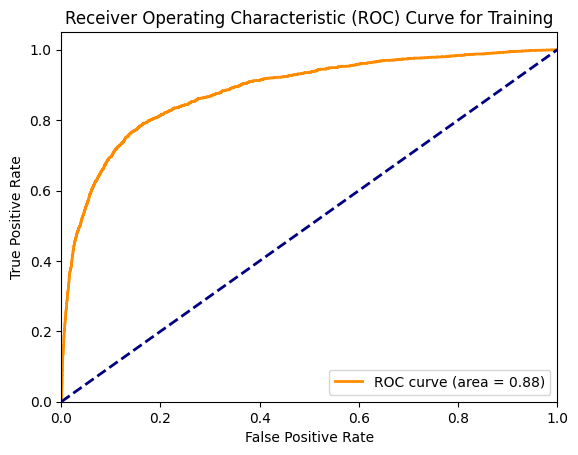

AUROC for Validation: 0.88


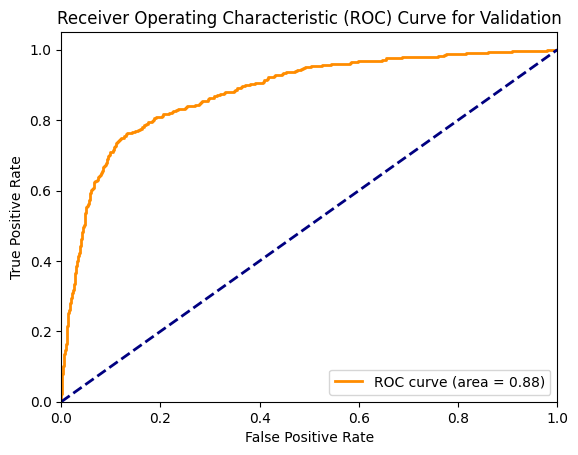

F1 score Training: 64.07%
F1 score Validation: 62.69%


(array([0.08740791, 0.61206612, 0.41028544, ..., 0.04771174, 0.42715841,
        0.2297738 ]),
 array([0.12577864, 0.18162701, 0.25901175, ..., 0.14423358, 0.22745674,
        0.2561721 ]))

In [82]:
predict_evaluate_raw_df(model5, scaler, encoder, numeric_cols, categorical_cols, target_col, train_raw_df)

З усіх моделей кращою виглядає модель 3. Спробуємо для неї також відредагувати threshold

Accuracy: 82.40%
Accuracy: 80.93%
AUROC for Training: 0.88


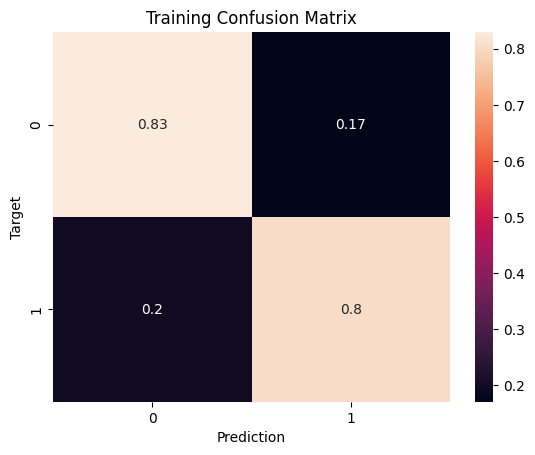

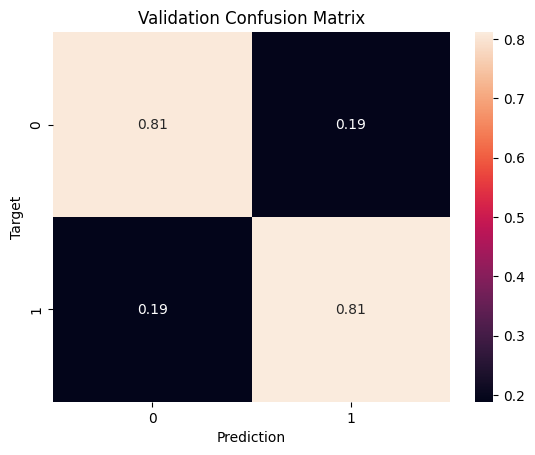

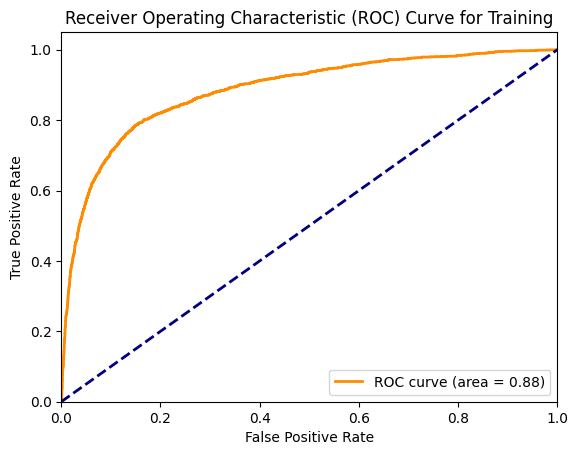

AUROC for Validation: 0.88


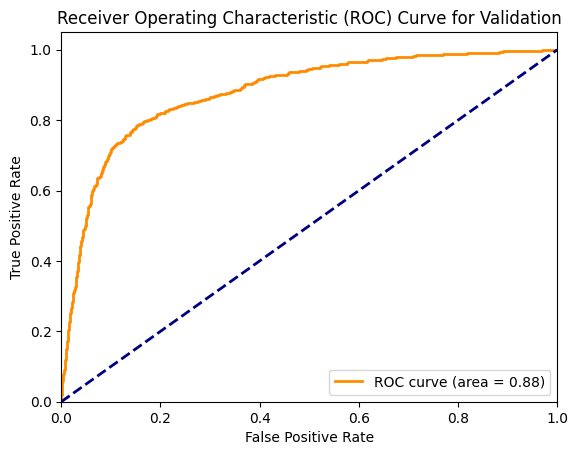

F1 score Training: 64.96%
F1 score Validation: 63.38%


In [86]:
prob_train, prob_val = predict_evaluate_raw_df(model3, scaler, encoder, numeric_cols, categorical_cols, target_col, train_raw_df)

In [108]:
custom_threshold = 0.4

In [109]:
custom_preds_train = (prob_train >= custom_threshold).astype(int)
custom_preds_val = (prob_val >= custom_threshold).astype(int)

In [110]:
print(f"Train F1-score with threshold {custom_threshold}: {f1_score(train_targets, custom_preds_train)*100:.2f}%")
print(f"\nValidation F1-score with threshold {custom_threshold}: {f1_score(val_targets, custom_preds_val)*100:.2f}%")
print("\nTrain New Confusion Matrix:\n", confusion_matrix(train_targets, custom_preds_train, normalize='true'))
print("\nValidation New Confusion Matrix:\n", confusion_matrix(val_targets, custom_preds_val, normalize='true'))

Train F1-score with threshold 0.4: 59.83%

Validation F1-score with threshold 0.4: 58.23%

Train New Confusion Matrix:
 [[0.74858757 0.25141243]
 [0.15315315 0.84684685]]

Validation New Confusion Matrix:
 [[0.72552301 0.27447699]
 [0.14754098 0.85245902]]


Отримали найкращий результат з усіх моделей. Таким чином, найкраща з моделей має наступні параметри:
- solver='liblinear'
- penalty='l1'
- class_weight='balanced'
- threshold 0.4

11. Зчитайте дані з `test.csv` в змінну `test_raw_df`. Зробіть передбачення для кожного рядка даних з функцією з попереднього завдання і запишіть результат в нову колонку `Exited` в датафреймі `test_raw_df`.

In [111]:
test_raw_df = pd.read_csv('/content/drive/MyDrive/ML DS/Module 2/Bank Customer Churn Prediction/test.csv')#, index_col=0)

In [112]:
test_raw_df.head()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,15000,15594796.0,Chu,584.0,Germany,Male,30.0,2.0,146053.66,1.0,1.0,1.0,157891.86
1,15001,15642821.0,Mazzi,551.0,France,Male,39.0,5.0,0.00,2.0,1.0,1.0,67431.28
2,15002,15716284.0,Onyekachi,706.0,France,Male,43.0,8.0,0.00,2.0,1.0,0.0,156768.45
3,15003,15785078.0,Martin,717.0,Spain,Male,45.0,3.0,0.00,1.0,1.0,1.0,166909.87
4,15004,15662955.0,Kenechukwu,592.0,Spain,Male,43.0,8.0,0.00,2.0,1.0,1.0,143681.97


In [113]:
test_raw_df['Exited'] = predict_raw_df(model3, scaler, encoder, numeric_cols, categorical_cols, test_raw_df)

In [114]:
test_raw_df.head()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15000,15594796.0,Chu,584.0,Germany,Male,30.0,2.0,146053.66,1.0,1.0,1.0,157891.86,0.220871
1,15001,15642821.0,Mazzi,551.0,France,Male,39.0,5.0,0.00,2.0,1.0,1.0,67431.28,0.136137
2,15002,15716284.0,Onyekachi,706.0,France,Male,43.0,8.0,0.00,2.0,1.0,0.0,156768.45,0.414756
3,15003,15785078.0,Martin,717.0,Spain,Male,45.0,3.0,0.00,1.0,1.0,1.0,166909.87,0.473187
4,15004,15662955.0,Kenechukwu,592.0,Spain,Male,43.0,8.0,0.00,2.0,1.0,1.0,143681.97,0.209864


12. Зчитайте файл 'sample_submission.csv' і зповніть колонку `Exited` передбаченими вашою моделлю значеннями для кожного відповідного `id` клієнта.
Виведіть перші 5 рядків фінального датасету, збережіть результат в файл `submission_log_reg.csv` (УВАГА! не запишіть випадково ще індекси рядків!) і здайте цей файл на Kaggle зі свого профіля натиснувши `Submit Prediction`.

In [115]:
submission_log_reg_df = pd.read_csv('/content/drive/MyDrive/ML DS/Module 2/Bank Customer Churn Prediction/sample_submission.csv')#, index_col=0)

In [116]:
submission_log_reg_df.head()

,id,Exited
0,15000,0.5
1,15001,0.5
2,15002,0.5
3,15003,0.5
4,15004,0.5


In [117]:
submission_log_reg_df['Exited'] = test_raw_df['Exited']

In [118]:
submission_log_reg_df.head()

,id,Exited
0,15000,0.220871
1,15001,0.136137
2,15002,0.414756
3,15003,0.473187
4,15004,0.209864


In [119]:
submission_log_reg_df.to_csv(save_path + 'submission_log_reg.csv', index=False)

In [120]:
df=pd.read_csv(save_path+"submission_log_reg.csv")
df.columns
df.head()

,id,Exited
0,15000,0.220871
1,15001,0.136137
2,15002,0.414756
3,15003,0.473187
4,15004,0.209864
